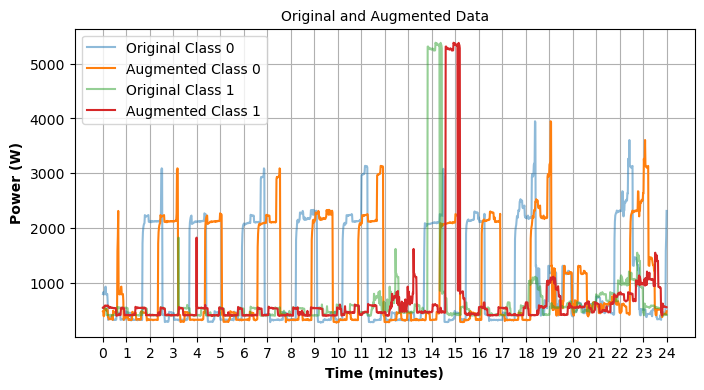

Augmented training data saved to: C:\abraham20230120\test_power_psa\dataset\psa_data_home_A_train_augmented.csv
Augmented test data saved to: C:\abraham20230120\test_power_psa\dataset\psa_data_home_A_test_augmented.csv


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the CSV data into DataFrames
train_csv_path = "C:\\abraham20230120\\test_power_psa\\dataset\\psa_data_home_A_train.csv"
test_csv_path = "C:\\abraham20230120\\test_power_psa\\dataset\\psa_data_home_A_test.csv"
train_df = pd.read_csv(train_csv_path)
test_df = pd.read_csv(test_csv_path)

# Augmentation parameters
num_augmentations = 60
min_offset = 0
max_offset = 59

# Create a list to store augmented data for training and test sets
augmented_train_data = []
augmented_test_data = []

# Data augmentation loop for training set
for index, row in train_df.iterrows():
    # Extract the original feature vector (X) and label (Y) from the row
    original_X = row[:1441]  # Assuming your data is in columns 0 to 1441 (0 to 24 hours and label)
    original_Y = row['Label']  # Replace 'Label' with your actual label column name
    
    for _ in range(num_augmentations):
        # Generate a random offset between min_offset and max_offset
        offset = np.random.randint(min_offset, max_offset + 1)
        
        # Circularly shift the feature vector (X) by the offset
        shifted_X = np.roll(original_X[:-1], offset)  # Exclude the label column
        
        # Append the shifted feature vector and label to the augmented data list for training
        augmented_train_data.append({'X': shifted_X, 'Y': original_Y})

# Data augmentation loop for test set (same as training)
for index, row in test_df.iterrows():
    original_X = row[:1441]
    original_Y = row['Label']
    
    for _ in range(num_augmentations):
        offset = np.random.randint(min_offset, max_offset + 1)
        shifted_X = np.roll(original_X[:-1], offset)
        augmented_test_data.append({'X': shifted_X, 'Y': original_Y})

# Create new DataFrames for the augmented data
augmented_train_df = pd.DataFrame(augmented_train_data)
augmented_test_df = pd.DataFrame(augmented_test_data)

# Define output file paths
train_output_csv_path = train_csv_path.replace(".csv", "_augmented.csv")
test_output_csv_path = test_csv_path.replace(".csv", "_augmented.csv")

# Save the augmented data to new CSV files for training and test sets
augmented_train_df.to_csv(train_output_csv_path, index=False)
augmented_test_df.to_csv(test_output_csv_path, index=False)

# Visualize the original and augmented data for both classes with different colors, showing time axis for 24 hours
# plt.figure(figsize=(12, 6))
plt.figure(figsize=(8, 4))
for class_label in [0, 1]:
    # Original data points
    original_class_data = train_df[train_df['Label'] == class_label].iloc[0]
    plt.plot(np.arange(1440), original_class_data[:1440], label=f'Original Class {class_label}', alpha=0.5)

    # Augmented data points
    augmented_class_data = augmented_train_df[augmented_train_df['Y'] == class_label].iloc[0]
    plt.plot(np.arange(1440), augmented_class_data['X'], label=f'Augmented Class {class_label}')

plt.title('Original and Augmented Data', fontsize=10)
plt.xlabel('Time (minutes)', fontsize=10, fontweight='bold')
plt.ylabel('Power (W)', fontsize=10, fontweight='bold')
plt.xticks(np.arange(0, 1441, step=60), labels=np.arange(0, 25, step=1))  # Show time axis for 24 hours
plt.grid(True)
plt.legend(fontsize=10)
plt.savefig(r'C:\Users\olufe\projects\Journal\Diagrams\Data_augmentation_HomeA_train_test.png',bbox_inches='tight')
plt.show()

# Print the paths to the saved augmented CSV files
print(f"Augmented training data saved to: {train_output_csv_path}")
print(f"Augmented test data saved to: {test_output_csv_path}")


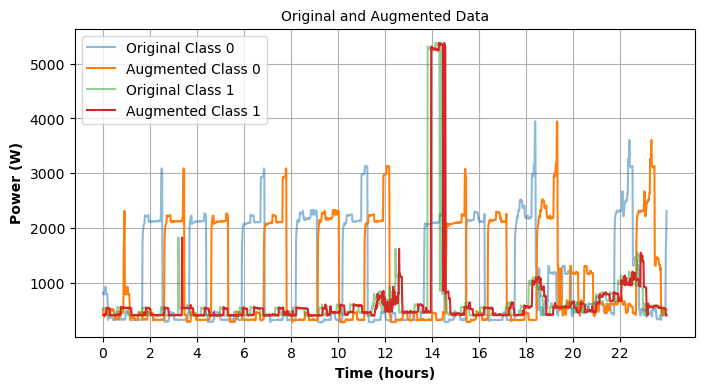

Augmented data saved to: C:\abraham20230120\test_power_psa\dataset\psa_data_home_A_train_augmented.csv


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the CSV data into a DataFrame
csv_path = "C:\\abraham20230120\\test_power_psa\\dataset\\psa_data_home_A_train.csv"
df = pd.read_csv(csv_path)

# Augmentation parameters
num_augmentations = 60
min_offset = 0
max_offset = 59

# Create a list to store augmented data
augmented_data = []

# Data augmentation loop
for index, row in df.iterrows():
    # Extract the original feature vector (X) and label (Y) from the row
    original_X = row[:1441]  # Assuming your data is in columns 0 to 1441 (0 to 24 hours and label)
    original_Y = row['Label']  # Replace 'Label' with your actual label column name
    
    for _ in range(num_augmentations):
        # Generate a random offset between min_offset and max_offset in minutes
        offset_minutes = np.random.randint(min_offset, max_offset + 1)
        
        # Circularly shift the feature vector (X) by the offset in columns
        shifted_X = np.roll(original_X[:-1], offset_minutes)  # Exclude the label column
        
        # Append the shifted feature vector and label to the augmented data list
        augmented_data.append({'X': shifted_X, 'Y': original_Y})

# Create a new DataFrame for the augmented data
augmented_df = pd.DataFrame(augmented_data)

# Define an output file path
output_csv_path = csv_path.replace(".csv", "_augmented.csv")

# Save the augmented data to a new CSV file
augmented_df.to_csv(output_csv_path, index=False)

# Visualize the original and augmented data for both classes with different colors, showing time axis in hours
# plt.figure(figsize=(12, 6))
plt.figure(figsize=(8, 4))
for class_label in [0, 1]:
    # Original data points
    original_class_data = df[df['Label'] == class_label].iloc[0]
    plt.plot(np.arange(1440), original_class_data[:1440], label=f'Original Class {class_label}', alpha=0.5)

    # Augmented data points
    augmented_class_data = augmented_df[augmented_df['Y'] == class_label].iloc[0]
    plt.plot(np.arange(1440), augmented_class_data['X'], label=f'Augmented Class {class_label}')

plt.title('Original and Augmented Data', fontsize=10)
plt.xlabel('Time (hours)', fontsize=10, fontweight='bold')
plt.ylabel('Power (W)', fontsize=10, fontweight='bold')
plt.xticks(np.arange(0, 1381, step=120), labels=np.arange(0, 24, step=2))  # Show time axis in hours
plt.grid(True)
plt.legend(fontsize=10)
plt.savefig(r'C:\Users\olufe\projects\Journal\Diagrams\Data_augmentation_sample_HomeA_train.png',bbox_inches='tight')
plt.show()

# Print the path to the saved augmented CSV file
print(f"Augmented data saved to: {output_csv_path}")


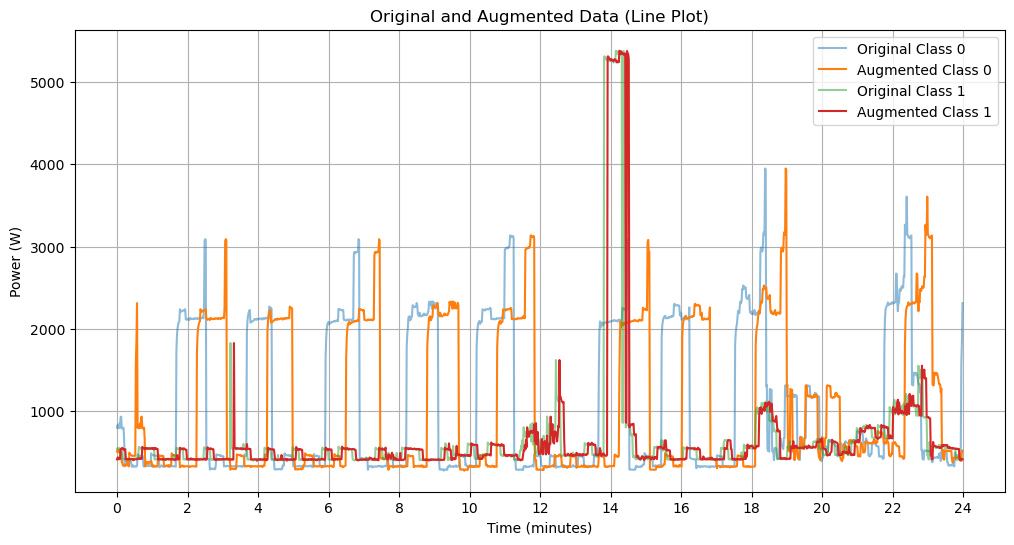

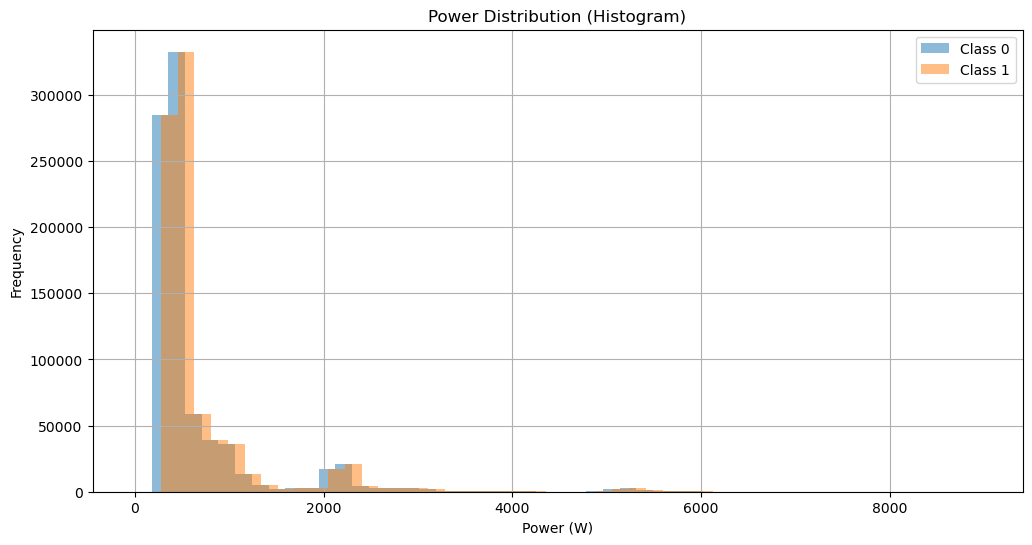

Augmented data saved to: C:\abraham20230120\test_power_psa\dataset\psa_data_home_A_train_augmented.csv


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the CSV data into a DataFrame
csv_path = "C:\\abraham20230120\\test_power_psa\\dataset\\psa_data_home_A_train.csv"
df = pd.read_csv(csv_path)

# Augmentation parameters
num_augmentations = 60
min_offset = 0
max_offset = 59

# Create a list to store augmented data
augmented_data = []

# Data augmentation loop
for index, row in df.iterrows():
    # Extract the original feature vector (X) and label (Y) from the row
    original_X = row[:1441]  # Assuming your data is in columns 0 to 1441 (0 to 24 hours and label)
    original_Y = row['Label']  # Replace 'Label' with your actual label column name
    
    for _ in range(num_augmentations):
        # Generate a random offset between min_offset and max_offset in minutes
        offset_minutes = np.random.randint(min_offset, max_offset + 1)
        
        # Circularly shift the feature vector (X) by the offset in columns
        shifted_X = np.roll(original_X[:-1], offset_minutes)  # Exclude the label column
        
        # Append the shifted feature vector and label to the augmented data list
        augmented_data.append({'X': shifted_X, 'Y': original_Y})

# Create a new DataFrame for the augmented data
augmented_df = pd.DataFrame(augmented_data)

# Define an output file path
output_csv_path = csv_path.replace(".csv", "_augmented.csv")

# Save the augmented data to a new CSV file
augmented_df.to_csv(output_csv_path, index=False)

# Visualize the original and augmented data for both classes with line plots
plt.figure(figsize=(12, 6))
for class_label in [0, 1]:
    # Original data points
    original_class_data = df[df['Label'] == class_label].iloc[0]
    plt.plot(np.arange(1440), original_class_data[:1440], label=f'Original Class {class_label}', alpha=0.5)

    # Augmented data points
    augmented_class_data = augmented_df[augmented_df['Y'] == class_label].iloc[0]
    plt.plot(np.arange(1440), augmented_class_data['X'], label=f'Augmented Class {class_label}')

plt.title('Original and Augmented Data (Line Plot)', fontsize=10)
plt.xlabel('Time (minutes)', fontsize=10, fontweight='bold')
plt.ylabel('Power (W)', fontsize=10, fontweight='bold')
plt.xticks(np.arange(0, 1441, step=120), labels=np.arange(0, 25, step=2))  # Show time axis in hours
plt.grid(True)
plt.legend(fontsize=10)
plt.savefig(r'C:\Users\olufe\projects\Journal\Diagrams\Data_augmentation_sample_HomeA.png',bbox_inches='tight')
plt.show()

# Create histograms to visualize power distribution for both classes
plt.figure(figsize=(12, 6))
for class_label in [0, 1]:
    class_data = df[df['Label'] == class_label]
    plt.hist(class_data.iloc[:, :1440].values.flatten(), bins=50, alpha=0.5, label=f'Class {class_label}')

plt.title('Power Distribution (Histogram)')
plt.xlabel('Power (W)')
plt.ylabel('Frequency')
plt.grid(True)
plt.legend()
plt.savefig(r'C:\Users\olufe\projects\Journal\Diagrams\Power_Distribution_Histog_HomeA.png',bbox_inches='tight')
plt.show()

# Print the path to the saved augmented CSV file
print(f"Augmented data saved to: {output_csv_path}")


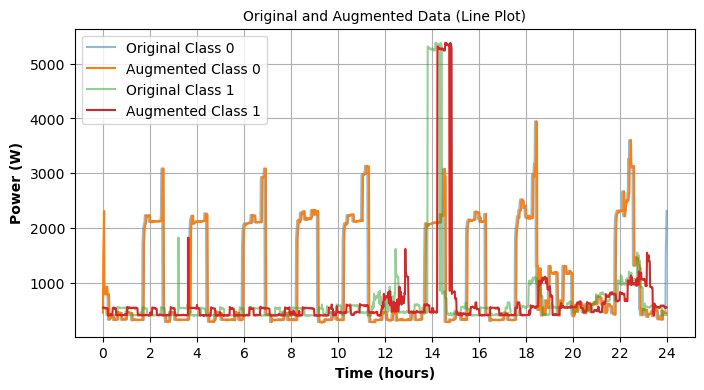

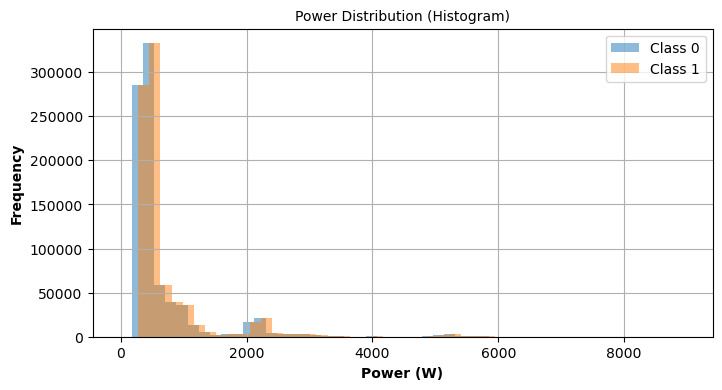

Augmented data saved to: C:\abraham20230120\test_power_psa\dataset\psa_data_home_A_train_augmented.csv


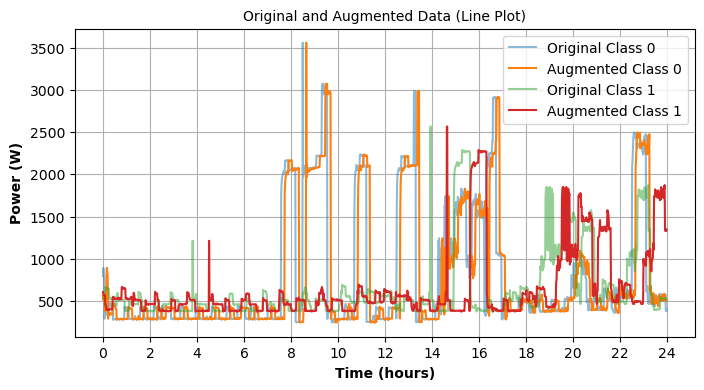

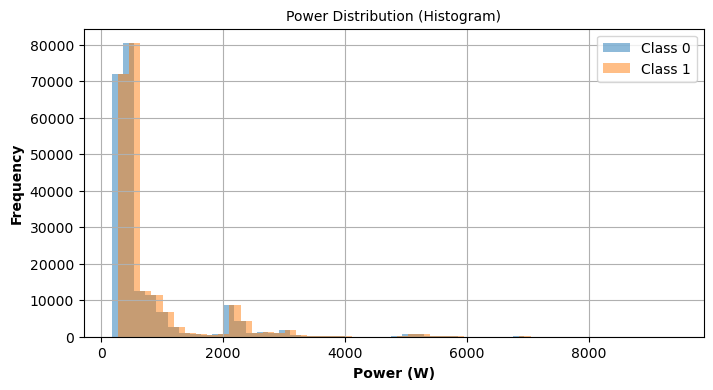

Augmented data saved to: C:\abraham20230120\test_power_psa\dataset\psa_data_home_A_test_augmented.csv


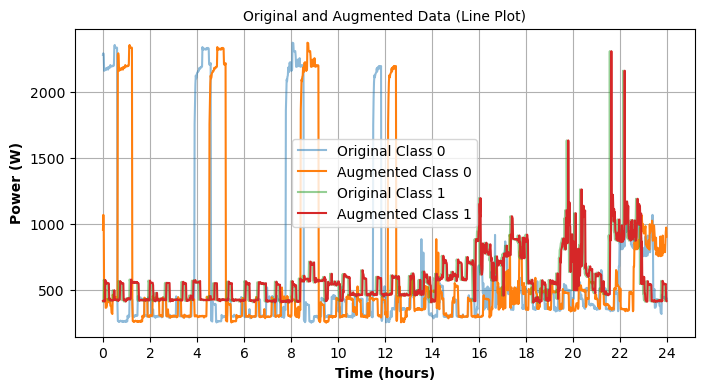

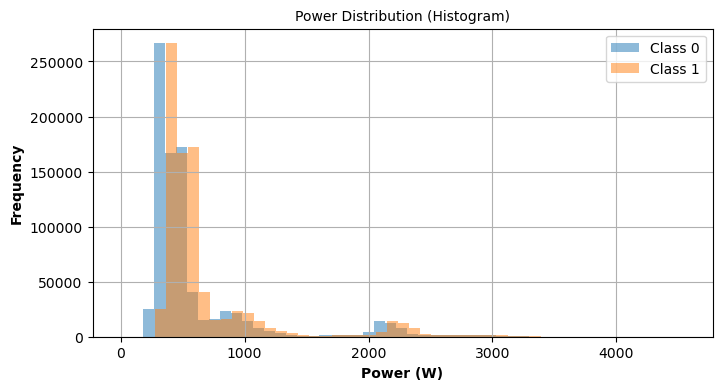

Augmented data saved to: C:\abraham20230120\test_power_psa\dataset\psa_data_home_B_train_augmented.csv


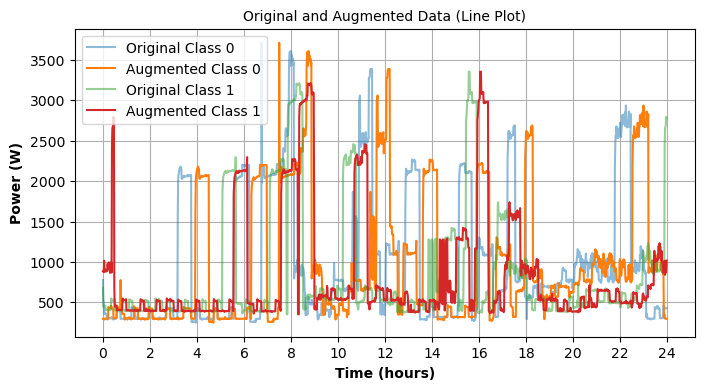

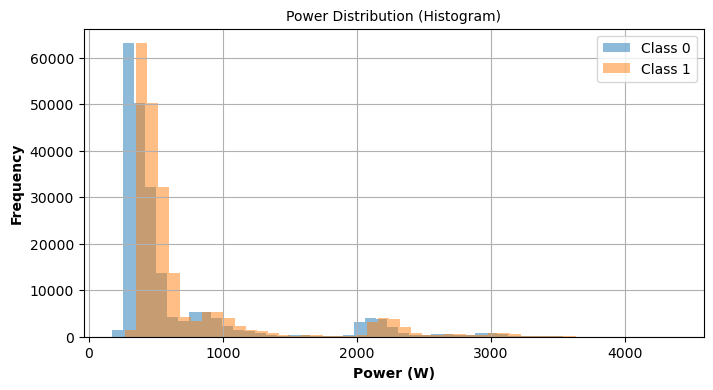

Augmented data saved to: C:\abraham20230120\test_power_psa\dataset\psa_data_home_B_test_augmented.csv


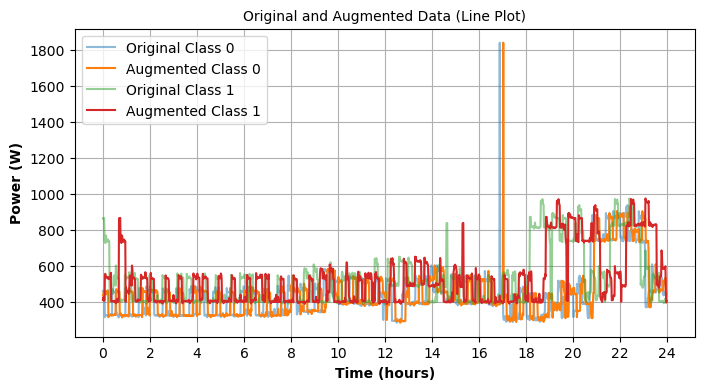

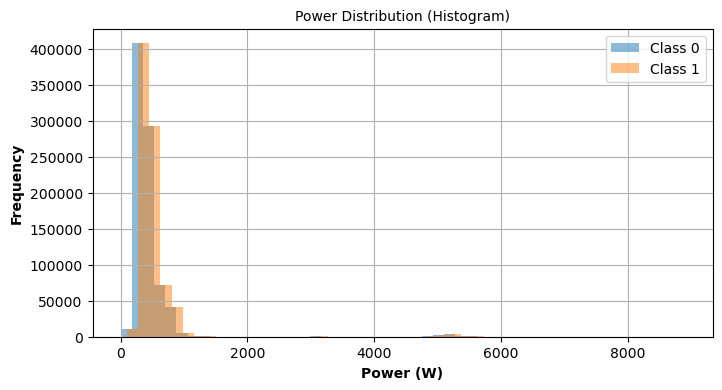

Augmented data saved to: C:\abraham20230120\test_power_psa\dataset\psa_data_home_C_train_augmented.csv


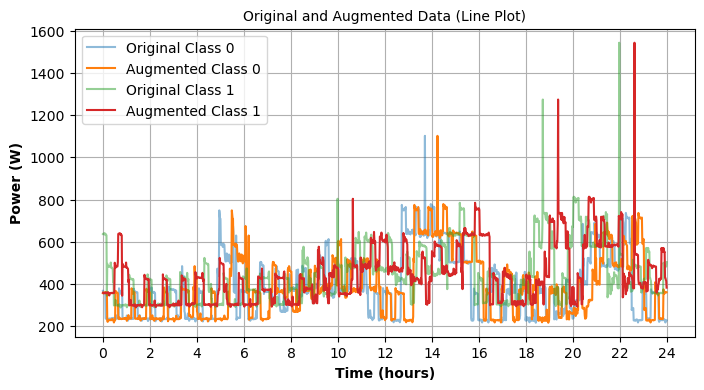

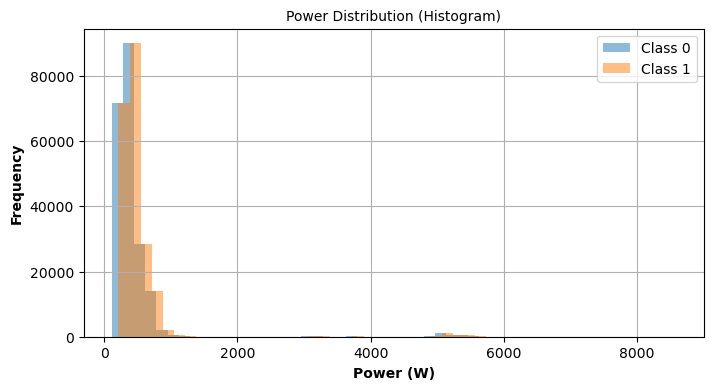

Augmented data saved to: C:\abraham20230120\test_power_psa\dataset\psa_data_home_C_test_augmented.csv


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# List of CSV file paths
csv_paths = [
    "C:\\abraham20230120\\test_power_psa\\dataset\\psa_data_home_A_train.csv",
    "C:\\abraham20230120\\test_power_psa\\dataset\\psa_data_home_A_test.csv",
    "C:\\abraham20230120\\test_power_psa\\dataset\\psa_data_home_B_train.csv",
    "C:\\abraham20230120\\test_power_psa\\dataset\\psa_data_home_B_test.csv",
    "C:\\abraham20230120\\test_power_psa\\dataset\\psa_data_home_C_train.csv",
    "C:\\abraham20230120\\test_power_psa\\dataset\\psa_data_home_C_test.csv"
]

# Augmentation parameters
num_augmentations = 60
min_offset = 0
max_offset = 59

# Function to perform data augmentation
def perform_augmentation(df):
    augmented_data = []
    for index, row in df.iterrows():
        original_X = row[:1441]
        original_Y = row['Label']
        
        for _ in range(num_augmentations):
            offset_minutes = np.random.randint(min_offset, max_offset + 1)
            shifted_X = np.roll(original_X[:-1], offset_minutes)
            augmented_data.append({'X': shifted_X, 'Y': original_Y})
    
    augmented_df = pd.DataFrame(augmented_data)
    return augmented_df

# Process each CSV file
for csv_path in csv_paths:
    # Load the CSV data into a DataFrame
    df = pd.read_csv(csv_path)
    
    # Define an output file path
    output_csv_path = os.path.splitext(csv_path)[0] + "_augmented.csv"
    
    # Perform data augmentation
    augmented_df = perform_augmentation(df)
    
    # Save the augmented data to a new CSV file
    augmented_df.to_csv(output_csv_path, index=False)
    
    # Visualize the original and augmented data for both classes
#     plt.figure(figsize=(12, 6))
    plt.figure(figsize=(8, 4))
    for class_label in [0, 1]:
        original_class_data = df[df['Label'] == class_label].iloc[0]
        plt.plot(np.arange(1440), original_class_data[:1440], label=f'Original Class {class_label}', alpha=0.5)

        augmented_class_data = augmented_df[augmented_df['Y'] == class_label].iloc[0]
        plt.plot(np.arange(1440), augmented_class_data['X'], label=f'Augmented Class {class_label}')

    plt.title('Original and Augmented Data (Line Plot)', fontsize=10)
    plt.xlabel('Time (hours)', fontsize=10, fontweight='bold')
    plt.ylabel('Power (W)', fontsize=10, fontweight='bold')
    plt.xticks(np.arange(0, 1441, step=120), labels=np.arange(0, 25, step=2))  # Show time axis in hours
    plt.grid(True)
    plt.legend(fontsize=10)
    plt.savefig(r'C:\Users\olufe\projects\Journal\Diagrams\Data_augmentation_for_all_sample.png',bbox_inches='tight')
    plt.show()

    # Create histograms to visualize power distribution for both classes
#     plt.figure(figsize=(12, 6))
    plt.figure(figsize=(8, 4))
    for class_label in [0, 1]:
        class_data = df[df['Label'] == class_label]
        plt.hist(class_data.iloc[:, :1440].values.flatten(), bins=50, alpha=0.5, label=f'Class {class_label}')

    plt.title('Power Distribution (Histogram)', fontsize=10)
    plt.xlabel('Power (W)', fontsize=10, fontweight='bold')
    plt.ylabel('Frequency', fontsize=10, fontweight='bold')
    plt.grid(True)
    plt.legend(fontsize=10)
    plt.savefig(r'C:\Users\olufe\projects\Journal\Diagrams\Power_Distribution_Histogram_all_data_sample.png',bbox_inches='tight')
    plt.show()

    # Print the path to the saved augmented CSV file
    print(f"Augmented data saved to: {output_csv_path}")


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os  # Import the os module for file path manipulation

# List of CSV file paths
csv_files = [
    "C:\\abraham20230120\\test_power_psa\\dataset\\psa_data_home_A_train.csv",
    "C:\\abraham20230120\\test_power_psa\\dataset\\psa_data_home_B_test.csv",
    "C:\\abraham20230120\\test_power_psa\\dataset\\psa_data_home_B_train.csv",
    "C:\\abraham20230120\\test_power_psa\\dataset\\psa_data_home_C_test.csv",
    "C:\\abraham20230120\\test_power_psa\\dataset\\psa_data_home_C_train.csv",
    "C:\\abraham20230120\\test_power_psa\\dataset\\psa_data_home_A_test.csv"
]

# Output directory for saving PNG files
output_directory = "C:\\Users\\olufe\\projects\\Journal\\Diagrams\\"

# Create the output directory if it doesn't exist
os.makedirs(output_directory, exist_ok=True)

# Augmentation parameters
num_augmentations = 60
min_offset = 0
max_offset = 59

# Loop through each CSV file
for csv_path in csv_files:
    # Load the CSV data into a DataFrame
    df = pd.read_csv(csv_path)
    
    # Create a list to store augmented data
    augmented_data = []

    # Data augmentation loop
    for index, row in df.iterrows():
        # Extract the original feature vector (X) and label (Y) from the row
        original_X = row[:1440]  # Assuming your data is in columns 0 to 1440 (0 to 24 hours)
        original_Y = row['Label']  # Replace 'label_column_name' with your actual label column name

        for _ in range(num_augmentations):
            # Generate a random offset between min_offset and max_offset
            offset = np.random.randint(min_offset, max_offset + 1)

            # Circularly shift the feature vector (X) by the offset
            shifted_X = np.roll(original_X, offset)

            # Append the shifted feature vector and label to the augmented data list
            augmented_data.append({'X': shifted_X, 'Y': original_Y})

    # Create a new DataFrame for the augmented data
    augmented_df = pd.DataFrame(augmented_data)

    # Define an output file path for the augmented CSV
    output_csv_path = csv_path.replace(".csv", "_augmented.csv")

    # Save the augmented data to a new CSV file
    augmented_df.to_csv(output_csv_path, index=False)

    # Visualize the original and augmented data for one example (train and test combined)
    original_example = augmented_data[0]
    plt.figure(figsize=(12, 6))
    plt.subplot(2, 1, 1)
    plt.title('Original Data Example')
    plt.plot(original_example['X'])
    plt.xlabel('Time (minutes)')
    plt.ylabel('Power (W)')
    plt.grid(True)


    plt.tight_layout()
    
    # Define the output PNG file path for the combined train and test figures
    output_png_path = os.path.join(output_directory, f"{os.path.basename(csv_path).replace('.csv', '_combined.png')}")

    # Save the figure as a PNG file
    plt.savefig(output_png_path, bbox_inches='tight')
    
    # Close the figure to release resources
    plt.close()

    # Print the path to the saved augmented CSV file and combined PNG file
    print(f"Augmented data saved to: {output_csv_path}")
    print(f"Combined PNG image saved to: {output_png_path}")


Augmented data saved to: C:\abraham20230120\test_power_psa\dataset\psa_data_home_A_train_augmented.csv
Combined PNG image saved to: C:\Users\olufe\projects\Journal\Diagrams\psa_data_home_A_train_combined.png
Augmented data saved to: C:\abraham20230120\test_power_psa\dataset\psa_data_home_B_test_augmented.csv
Combined PNG image saved to: C:\Users\olufe\projects\Journal\Diagrams\psa_data_home_B_test_combined.png
Augmented data saved to: C:\abraham20230120\test_power_psa\dataset\psa_data_home_B_train_augmented.csv
Combined PNG image saved to: C:\Users\olufe\projects\Journal\Diagrams\psa_data_home_B_train_combined.png
Augmented data saved to: C:\abraham20230120\test_power_psa\dataset\psa_data_home_C_test_augmented.csv
Combined PNG image saved to: C:\Users\olufe\projects\Journal\Diagrams\psa_data_home_C_test_combined.png
Augmented data saved to: C:\abraham20230120\test_power_psa\dataset\psa_data_home_C_train_augmented.csv
Combined PNG image saved to: C:\Users\olufe\projects\Journal\Diagrams